# Model Doplyment
------
Making your machine learning model available to someone/something else. -> example: app/website/program.
 [![image.png](https://i.postimg.cc/sfKQMrBB/image.png)](https://postimg.cc/14n5dbrP)

----
During training, we use three datasets: training, validation, and testing. However, real-world data exists as well, and it can only be tested after deployment to measure model performance. Real-world data includes noise and varying conditions that can reveal a model's fragility or robustness.

----

**MLOps:** machine learning operations: is a set of practices that aims to **deploy** and maintain ML models in production reliably and efficiently.

----


* What is the most ideal ML deployment scenario?
  * Works every time.
  * Speed of light. (fast) -> slow model is not preferable.
---
* Where is the model?
  * On-device. (edge) -> like, Tesla autopilot, text detection must also be on device so we  get output in real time.
    * Smaller model, less performance, faster inference.

  * Cloud. (aws, hugging face, azure...) -> a remote computer that is not the actual device we use. -> we use cloud when we do have large models that does not fin in device.

    * Bigger model, better performance, slower inference because we need to send input to the cloud and wait for delay time until pred/outcome comes from the cloud.

#### Model Deployment Comparison Table

| Deployment Location                    |  Pros                                                                                                                                 | Cons                                                                                                         |
|----------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------|
| 🖥️ **On-device (edge/in-browser)**     | - **Speed:** Fast (no data leaves the device) <br> - **Privacy:** Fully private <br> - **Offline Access:** No internet required        | - **Compute Power:** Limited <br> - **Storage:** Smaller model size required <br> - **Development:** Device-specific skills needed |
| ☁️ **On cloud** *(remote compute)*     | - **Scalability:** Near unlimited compute <br> - **Flexibility:** Deploy once, use anywhere (API) <br> - **Integration:** Cloud ecosystem | - **Cost:** Can become expensive <br> - **Latency:** Slower due to data transfer <br> - **Privacy:** Data leaves the device |

-----
* How the model will function?
  * Online. (real-time)
  * Offline. (in batches)

#### **How’s my model going to function?**

|                                | **Offline prediction (batch/asynchronous)**                                      | **Online prediction (real-time/synchronous)**                                      |
|-------------------------------|-----------------------------------------------------------------------------------|------------------------------------------------------------------------------------|
| **Frequency**                 | Periodical, such as every 10 minutes or every four hours or once per day         | As soon as requests come (data comes in, prediction comes back ASAP)              |
| **Useful for**               | Processing/training on data when you don’t need immediate results                 | When predictions are required as soon as data comes in                            |
| **Optimized for**            | High throughput (such as making predictions/training on many samples at a time)  | Low latency/high frequency (fast results, often)                                  |
| **Example**                  | Recommendation engines, Apple photos app sorting, YouTube indexing/sorting, training models | FoodVision Mini, fraudulent transaction detection, spam detection, translation, Tesla self-driving vision system |

**Source:** *[Designing Machine Learning Systems](https://www.oreilly.com/library/view/designing-machine-learning/9781098107968/) book by Chip Huyen*

-----------

[onnx runtime](https://onnxruntime.ai/)

[Model deployment](https://bergum.medium.com/moving-ml-inference-from-the-cloud-to-the-edge-d6f98dbdb2e3)

[Real Time Inference on Raspberry Pi](https://docs.pytorch.org/tutorials/intermediate/realtime_rpi.html)


**Tools to help deploy machine learning models:**

* **On-device (mobile/edge):**  
  * [Google's ML Kit](https://developers.google.com/ml-kit)  
  * [Apple's Core ML](https://developer.apple.com/documentation/coreml)

* **Cloud:**  
  * [Google Cloud Vertex AI](https://cloud.google.com/vertex-ai)  
  * [AWS SageMaker](https://aws.amazon.com/sagemaker/)  
  * [Hugging Face & Gradio](https://huggingface.co/docs)  
  * [Azure Machine Learning](https://azure.microsoft.com/en-us/products/machine-learning/)

* **General:**  
  * [FastAPI](https://fastapi.tiangolo.com/)  
  * [TorchServe](https://pytorch.org/serve/)  - no longer maintained.
  * [Triton Inference Server](https://github.com/triton-inference-server/server) – production-grade multi-framework model server from NVIDIA  
  * [ONNX (Open Neural Network Exchange)](https://onnx.ai/) – for cross-framework model format and runtime  
  * [Docker](https://www.docker.com/) – for containerizing ML models and serving them reliably across platforms  
  * [BentoML](https://bentoml.com/) – unified framework for packaging and deploying ML models into APIs or containers

* **MLOps & Monitoring:**  
  * [MLflow](https://mlflow.org/) – experiment tracking, model registry, and deployment  
  * [Weights & Biases (W&B)](https://wandb.ai/) – real-time tracking of experiments, metrics, and artifacts  
  * [ClearML](https://clear.ml/) – open-source MLOps suite with experiment tracking, orchestration, and model serving  
  * [Kubeflow](https://kubeflow.org/) – Kubernetes-native platform for end-to-end ML pipelines  
  * [Neptune.ai](https://neptune.ai/) – lightweight metadata store for monitoring model training and evaluation



## 0. Getting Setup

In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

# TorchInfo
try:
    from torchinfo import summary
except ImportError:
    # Quiet pip install
    !pip install -q torchinfo
    from torchinfo import summary

# helper_functions.py
try:
    from helper_functions import set_seeds, download_data, plot_loss_curves
except ImportError:
    # Quiet git clone and file moves
    !git clone -q https://github.com/mrdbourke/pytorch-deep-learning/
    !mv pytorch-deep-learning/helper_functions.py . > /dev/null 2>&1
    !rm -rf pytorch-deep-learning
    from helper_functions import set_seeds, download_data, plot_loss_curves

# going_modular
try:
    from going_modular import data_setup, engine
except ImportError:
    !git clone -q https://github.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice/
    !mv pytorch-zero-to-mastery-MyPractice/going_modular . > /dev/null 2>&1
    !rm -rf pytorch-zero-to-mastery-MyPractice
    from going_modular import data_setup, engine

2.6.0+cu124
0.21.0+cu124


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Getting Data

In [ ]:
# Download Pizza, steak, and sushi images from github
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

[INFO] Did not find data/pizza_steak_sushi_20_percent directory, creating one...
[INFO] Downloading pizza_steak_sushi_20_percent.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi_20_percent.zip...
[INFO] Unzipping pizza_steak_sushi_20_percent.zip data...


In [ ]:
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

## 2. Food Vision Mini Model Deployment Experiment outline

### 3 questions
1. what is my most ideal machine learning deoyment scenario?
2. where is my model going to go?
3. how is my model going to function?

**FoodVision mini ideal use case:** A model that performs well and fast.

* Performs well: 95%+ accuracy.
* Fast: as close to real time or faster as possible (30FPS+ or 30ms Latency).
  * Latency: time for prediction to take place.

To try and achieve these goals, we are going to build two model experiments:
 1. EffNetB2 feature extractor.
 2. ViT feature extractor.

## 3. Creating an EffNetB2 feature extractor

Feature extractor = a term for a transfer learning model that has its base layers frozen and output layers customized to a certain problem.


### 3.1 create a function to make effnetb2 a feature extractor

In [ ]:
import torchvision
from torch import nn

def create_effnetb2(num_classes:int= 3, seed:int= 42):

  # 1. Setup the pretrained EffNetB2 wights
  effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

  # 2. Get the effnetb2 transform
  effnetb2_transforms = effnetb2_weights.transforms()

  # 3. Setup the pretrained model instance
  effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

  # 4. Freeze the base layers in the model
  for param in effnetb2.parameters():
    param.requires_grad=False

  # 5. Customize the head layers
  set_seeds(seed)
  effnetb2.classifier = nn.Sequential(
                                      nn.Dropout(p=0.3, inplace=True),
                                      nn.Linear(in_features=1408, out_features=num_classes, bias=True))
  return effnetb2, effnetb2_transforms

In [ ]:
effnetb2, effnetb2_transforms = create_effnetb2(num_classes=3, seed=42)
summary(model=effnetb2,
        input_size=(1,3,224,224),
        verbose=0, # how many details printed, 0 for minimal
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 97.7MB/s]


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 3.2 Creating DataLoaders for effnetb2

In [ ]:
# Create dataloaders
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=effnetb2_transforms,
                                                                               batch_size=32)

train_dataloader_effnetb2, test_dataloader_effnetb2, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7d8d81da2ad0>,
 ['pizza', 'steak', 'sushi'])

In [ ]:
len(train_dataloader_effnetb2), len(test_dataloader_effnetb2)

(15, 5)

### 3.3 Training effnetb2 feature extractor

In [ ]:
from going_modular import engine

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)

# Training function
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                       train_dataloader=train_dataloader_effnetb2,
                       test_dataloader=test_dataloader_effnetb2,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       epochs=10,
                       device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9839 | train_acc: 0.5667 | test_loss: 0.7367 | test_acc: 0.9409
Epoch: 2 | train_loss: 0.7369 | train_acc: 0.8271 | test_loss: 0.5524 | test_acc: 0.9375
Epoch: 3 | train_loss: 0.5330 | train_acc: 0.9083 | test_loss: 0.4984 | test_acc: 0.9597
Epoch: 4 | train_loss: 0.4669 | train_acc: 0.8958 | test_loss: 0.4127 | test_acc: 0.9472
Epoch: 5 | train_loss: 0.4245 | train_acc: 0.8938 | test_loss: 0.3767 | test_acc: 0.9659
Epoch: 6 | train_loss: 0.3944 | train_acc: 0.8875 | test_loss: 0.3303 | test_acc: 0.9625
Epoch: 7 | train_loss: 0.3691 | train_acc: 0.8771 | test_loss: 0.3285 | test_acc: 0.9324
Epoch: 8 | train_loss: 0.3828 | train_acc: 0.8771 | test_loss: 0.3009 | test_acc: 0.9688
Epoch: 9 | train_loss: 0.3106 | train_acc: 0.9208 | test_loss: 0.2851 | test_acc: 0.9659
Epoch: 10 | train_loss: 0.2790 | train_acc: 0.9500 | test_loss: 0.2703 | test_acc: 0.9563


### 3.4 Inspecting EffNetB2 loss curves

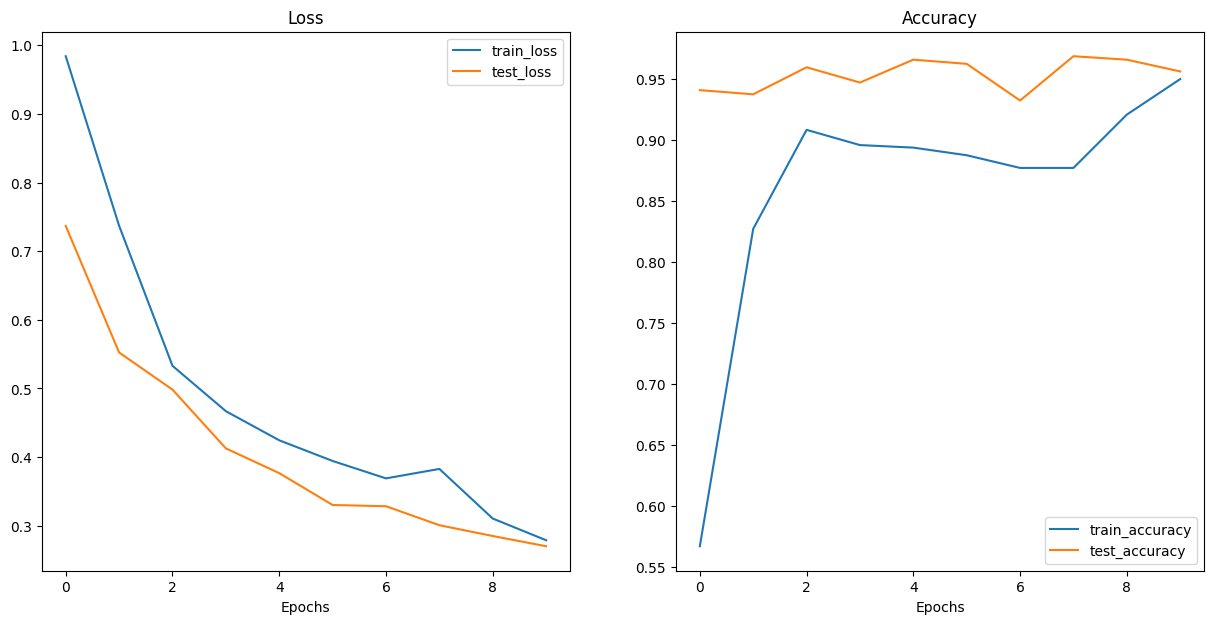

In [ ]:
plot_loss_curves(effnetb2_results)

### 3.5 Saving effnetb2 feature extractor


In [ ]:
from going_modular import utils

# Save the model
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="effnetb2.pth")

[INFO] Saving model to: models/effnetb2.pth


### 3.6 Inspecting the size of our EffNetB2 feature extractor

why important?
if we deploy our model to be used on mobile/website, ther are limited compute resources.

so if the model file is too large, we may not be able to run/store in target device

In [ ]:
from pathlib import Path

# Get the model size in bytes and convert to megabytes
pretrained_effnetb2_model_size = Path("models/effnetb2.pth").stat().st_size / (1024 * 1024)
print(f"Pretrained EffNetB2 feature extractor model size: {round(pretrained_effnetb2_model_size, 2)}MB.")

Pretrained EffNetB2 feature extractor model size: 29.83MB.


### 3.7 Collecting EffNetB2 feature extractor stats

In [ ]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
print(f"Total parameters: {effnetb2_total_params}")

Total parameters: 7705221


In [ ]:
# Create a dictionary with effnetb2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "total_params": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.27026137709617615,
 'test_acc': 0.95625,
 'total_params': 7705221,
 'model_size (MB)': 29.82549476623535}

## 4. Creating a ViT feature extractor

### 4.1 Create a function to create ViT model

In [ ]:



def create_ViT(num_classes:int=3, seed=42):
  # 1. Setup the pretrained ViT weights
  weights = torchvision.models.ViT_B_16_Weights.DEFAULT

  # 2. Get the pretrained ViT transform
  transform = weights.transforms()

  # 3. Create the pretrained ViT instance
  model = torchvision.models.vit_b_16(weights=weights)

  # 4. Freeze the the hidden layers
  for param in model.parameters():
    param.requires_grad = False

  set_seeds(seed)
  torch.manual_seed(seed)
  # 5. Customize the head layer to num classes
  model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))

  return model, transform

In [ ]:
vit, vit_transform = create_ViT(num_classes=3, seed=42)
summary(model=vit,
        input_size=(1,3,224,224),
        verbose=0, # how many details printed, 0 for minimal
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 124MB/s]


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 4.2 Create DataLoaders for vit feature extractor

In [ ]:
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                       test_dir=test_dir,
                                                                                       transform=vit_transform,
                                                                                       batch_size=32)
len(train_dataloader_vit), len(test_dataloader_vit), class_names

(15, 5, ['pizza', 'steak', 'sushi'])

### 4.3 training vit feature extractor


In [ ]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)

# Training function
set_seeds()
vit_results = engine.train(model=vit,
                       train_dataloader=train_dataloader_vit,
                       test_dataloader=test_dataloader_vit,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       epochs=10,
                       device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2614 | test_acc: 0.9409
Epoch: 2 | train_loss: 0.2197 | train_acc: 0.9437 | test_loss: 0.1492 | test_acc: 0.9688
Epoch: 3 | train_loss: 0.1534 | train_acc: 0.9583 | test_loss: 0.1125 | test_acc: 0.9750
Epoch: 4 | train_loss: 0.1304 | train_acc: 0.9604 | test_loss: 0.0961 | test_acc: 0.9722
Epoch: 5 | train_loss: 0.1079 | train_acc: 0.9688 | test_loss: 0.0821 | test_acc: 0.9784
Epoch: 6 | train_loss: 0.0981 | train_acc: 0.9750 | test_loss: 0.0776 | test_acc: 0.9812
Epoch: 7 | train_loss: 0.0908 | train_acc: 0.9812 | test_loss: 0.0727 | test_acc: 0.9756
Epoch: 8 | train_loss: 0.0729 | train_acc: 0.9854 | test_loss: 0.0645 | test_acc: 0.9875
Epoch: 9 | train_loss: 0.0647 | train_acc: 0.9854 | test_loss: 0.0606 | test_acc: 0.9750
Epoch: 10 | train_loss: 0.0558 | train_acc: 0.9854 | test_loss: 0.0613 | test_acc: 0.9750


### 4.4 Inspecting vit feture extractor results

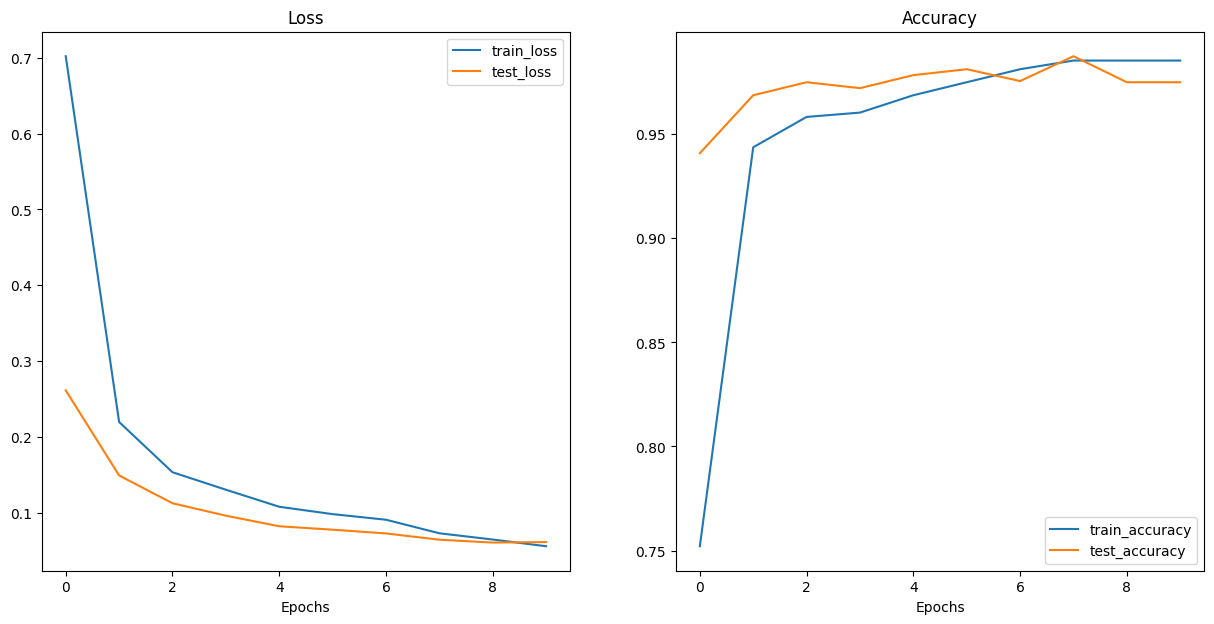

In [ ]:
plot_loss_curves(vit_results)

### 4.5 Saving vit feature extractor


In [ ]:
utils.save_model(model=vit,
                 target_dir="models",
                 model_name="vit.pth")

[INFO] Saving model to: models/vit.pth


### 4.6 Inspecting the size of vit feature extracor

In [ ]:
pretrained_vit_model_size = Path("models/vit.pth").stat().st_size / (1024 * 1024)
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
print(f"Pretrained ViT feature extractor model size: {round(pretrained_vit_model_size, 2)}MB.")
print(f"Total params: {vit_total_params}")

Pretrained ViT feature extractor model size: 327.35MB.
Total params: 85800963


4.7 Collecting vit feature extractor stats

In [ ]:
# Create a dictionary with effnetb2 statistics
vit_stats = {"test_loss": vit_results["test_loss"][-1],
                  "test_acc": vit_results["test_acc"][-1],
                  "total_params": vit_total_params,
                  "model_size (MB)": pretrained_vit_model_size}
vit_stats

{'test_loss': 0.06129768043756485,
 'test_acc': 0.975,
 'total_params': 85800963,
 'model_size (MB)': 327.3524341583252}

> Both models performs well with > 95% accuracy.

## 5. Making predictions with our trained models and timing them

to check which is faster +30FPS

To test speed:
1. Loop through images.
2. Time how long each model takes to make a prediction on the image.

To do so, we will create a function `pred_and_store()`, first we will find a list of test images paths.

In [ ]:
# Get all test data paths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/44810.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/2782998.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/420409.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1687143.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/2111981.jpg')]

### 5.1 Creating a function to loop across the test dataset

Steps to create `pred_and_store()`:
1. Create a function that takes: list of paths, trained pytorch model, series of transforms, list of target class names, and a target device.
2. Create an empty list (can return a full list of all predictions later.)
3. Loop through the target input paths (the rest of the steps will take place inside the loop.)
4. Create an empty dictionary for each sample (prediction statistics will go in here).
5. Get the sample path and ground truth class from the filepath.
6. Start the prediction timer.
7. Open the image using `PIL.Image.open(path)`.
8. Transform the image to be usable with a given model.
9. Prepare the model for inference by sending to target device and turning on `eval()` mode.
10. Turn on `torch.inference_mode()` and pass the target transformed image to the model and perform forward pass + calculate pred prob and pred class.
11. Add the pred prob and pred class to empty dictionary from step 4.
12. End the prediction timer started in step 6 and add the time to the prediction dictionary.
13. See if the predicted class matches the ground truth classs.
14. Append the updated prediction dictionary to the empty list of predictions we created in step 2.
15. Return the list of prediction dictionaries.



In [ ]:
from typing import Dict, List
import torch

from PIL import Image
import pathlib

from timeit import default_timer as timer
from tqdm.auto import tqdm

# 1. create a function that takes the previous arguments
def pred_and_store(paths_list: List[pathlib.Path],
                   model: torch.nn.Module,
                   transform: torchvision.transforms,
                   class_names: List[str],
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:

  # 2. Create an empty list to return a full list of predictions later
  pred_list = []

  # 3. Loop through the target input paths
  for path in tqdm(paths_list):
    # 4. create empty dict for each sample
    pred_dict = {}

    # 5. Get the file path and the class from the filepath
    pred_dict["image_path"] = path
    class_name = path.parent.stem
    pred_dict["class_name"] = class_name

    # 6. Start the prediction timer
    start_time = timer()

    # 7. Open the image using image.open(path)
    img = Image.open(path)

    # 8. Transform the image
    transformed_image = transform(img).unsqueeze(0).to(device)

    # 9. Prepare the model for inference
    model = model.to(device)
    model.eval()

    # 10. Turn on `torch.inference_mode()` and pass the target transformed image to the model and perform forward pass and pred prob and class
    with torch.inference_mode():
      pred_logit = model(transformed_image)
      pred_prob = torch.softmax(pred_logit.cpu(), dim=1)
      pred_class_idx = torch.argmax(pred_prob, dim=1).item()
      pred_class = class_names[pred_class_idx]
      pred_confidence = pred_prob[0][pred_class_idx].item()

    # 11. Add the pred prob and pred class to dictionary
    pred_dict["pred_prob"] = pred_confidence
    pred_dict["pred_class"] = pred_class

    # 12. End the prediction timer
    end_time = timer()
    pred_time = end_time - start_time
    pred_dict["pred_time"] = pred_time

    # 13. See if pred class match the actual class
    pred_dict["correct"] = class_name == pred_class

    # 14. A ppend the dict to the list
    pred_list.append(pred_dict)

    # Keep track of total pred time
    total_pred_time =+ pred_time

  print(f"[INFO] Total prediction time: {total_pred_time:.5f}\n")

  # 15. Return the list of predictions
  return pred_list

### 5.2 Making and timing predictions with EffNetB2

In [ ]:
effnetb2_pred_list = pred_and_store(paths_list=test_data_paths,
               model= effnetb2,
               transform= effnetb2_transforms,
               class_names=class_names)
effnetb2_pred_list[:3]

  0%|          | 0/150 [00:00<?, ?it/s]

[INFO] Total prediction time: 0.03334



[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/44810.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.7780044078826904,
  'pred_class': 'pizza',
  'pred_time': 0.10061636499995075,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/2782998.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.6723564863204956,
  'pred_class': 'pizza',
  'pred_time': 0.02879379500001278,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/420409.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.8541545867919922,
  'pred_class': 'pizza',
  'pred_time': 0.024835014999951,
  'correct': True}]

In [ ]:
# Turn the test_pred_list into a dataframe
import pandas as pd
effnetb2_pred_list_df = pd.DataFrame(effnetb2_pred_list)
effnetb2_pred_list_df[:5]

,image_path,class_name,pred_prob,pred_class,pred_time,correct
0,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.778004,pizza,0.100616,True
1,data/pizza_steak_sushi_20_percent/test/pizza/2...,pizza,0.672356,pizza,0.028794,True
2,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.854155,pizza,0.024835,True
3,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.898898,pizza,0.031537,True
4,data/pizza_steak_sushi_20_percent/test/pizza/2...,pizza,0.937138,pizza,0.039608,True


In [ ]:
effnetb2_pred_list_df.correct.value_counts()

,count
correct,
True,143
False,7


In [ ]:
# Find the average time per prediction
effnetb2_avg_time_per_pred = round(effnetb2_pred_list_df.pred_time.mean(), 4)
effnetb2_stats["time_per_pred"] = effnetb2_avg_time_per_pred
print(f"EffNetB2 average time per prediction: {effnetb2_avg_time_per_pred}")

EffNetB2 average time per prediction: 0.0334


### 5.3 Making and timing predictions with ViT

In [ ]:
vit_pred_list = pred_and_store(paths_list=test_data_paths,
               model= vit,
               transform= vit_transform,
               class_names=class_names)
vit_pred_list[:3]

  0%|          | 0/150 [00:00<?, ?it/s]

[INFO] Total prediction time: 0.01899



[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/44810.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9937973618507385,
  'pred_class': 'pizza',
  'pred_time': 0.03903629000001274,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/2782998.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9990314245223999,
  'pred_class': 'pizza',
  'pred_time': 0.03341795699998329,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/420409.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9989340901374817,
  'pred_class': 'pizza',
  'pred_time': 0.03248541099998192,
  'correct': True}]

In [ ]:
# Turn the test_pred_list into a dataframe
import pandas as pd
vit_pred_list_df = pd.DataFrame(vit_pred_list)
vit_pred_list_df[:5]

,image_path,class_name,pred_prob,pred_class,pred_time,correct
0,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.993797,pizza,0.039036,True
1,data/pizza_steak_sushi_20_percent/test/pizza/2...,pizza,0.999031,pizza,0.033418,True
2,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.998934,pizza,0.032485,True
3,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.998830,pizza,0.035604,True
4,data/pizza_steak_sushi_20_percent/test/pizza/2...,pizza,0.998385,pizza,0.033307,True


In [ ]:
vit_pred_list_df.correct.value_counts()

,count
correct,
True,146
False,4


In [ ]:
# Find the average time per prediction
vit_avg_time_per_pred = round(vit_pred_list_df.pred_time.mean(), 4)
vit_stats["time_per_pred"] = vit_avg_time_per_pred
print(f"ViT average time per prediction: {vit_avg_time_per_pred}")

ViT average time per prediction: 0.021


## 6. Comparing model results, prediction times and size

In [ ]:
# Turn stat dictionaries into DataFrames
df = pd.DataFrame([effnetb2_stats, vit_stats])

# Add column for model names
df["model"] = ["EffNetB2", "ViT"]

# Convert accuracy to precentage
df["test_acc"] = round(df["test_acc"] * 100, 2)

df.head()

,test_loss,test_acc,total_params,model_size (MB),time_per_pred,model
0,0.270261,95.62,7705221,29.825495,0.0334,EffNetB2
1,0.061298,97.50,85800963,327.352434,0.0210,ViT


Which model is better?
* `test_loss` (lower is better) - ViT
* `test_acc` (higher is better) - ViT
* `total_params` (generally lower is better, more parameters -> longer time to compute) - EffNetB2
  * Sometimes models with higher parameters can still perform fast
* `model_size` (for mobile deployiny, generally lower is better) - EffNetB2
* `time_per_pred` (lower on better also hughly dependent on the hardware) - ViT


Both models fail to achieve our goal of +30FPS.

In [ ]:
# Compare ViT to EffNetB2 across diff characterstics
pd.DataFrame(data=(df.set_index("model").loc["ViT"] / df.set_index("model").loc["EffNetB2"]),
             columns=["ViT to EffNetB2 ratios"]).T


,test_loss,test_acc,total_params,model_size (MB),time_per_pred
ViT to EffNetB2 ratios,0.226809,1.019661,11.135432,10.975591,0.628743


### 6.1 Visualizing the speed vs. performance tradeoff

we can do so with matplotlib:
1. Create a scatter plot from the comparison DataFrame to compare EffNetB2 and ViT across test accuracy and prediction time.
2. Add titles and labels to make our plot look nice.
3. Annotate the samples on the scatter plot so we knows what is going on.
4. Create a legend based on the model size.

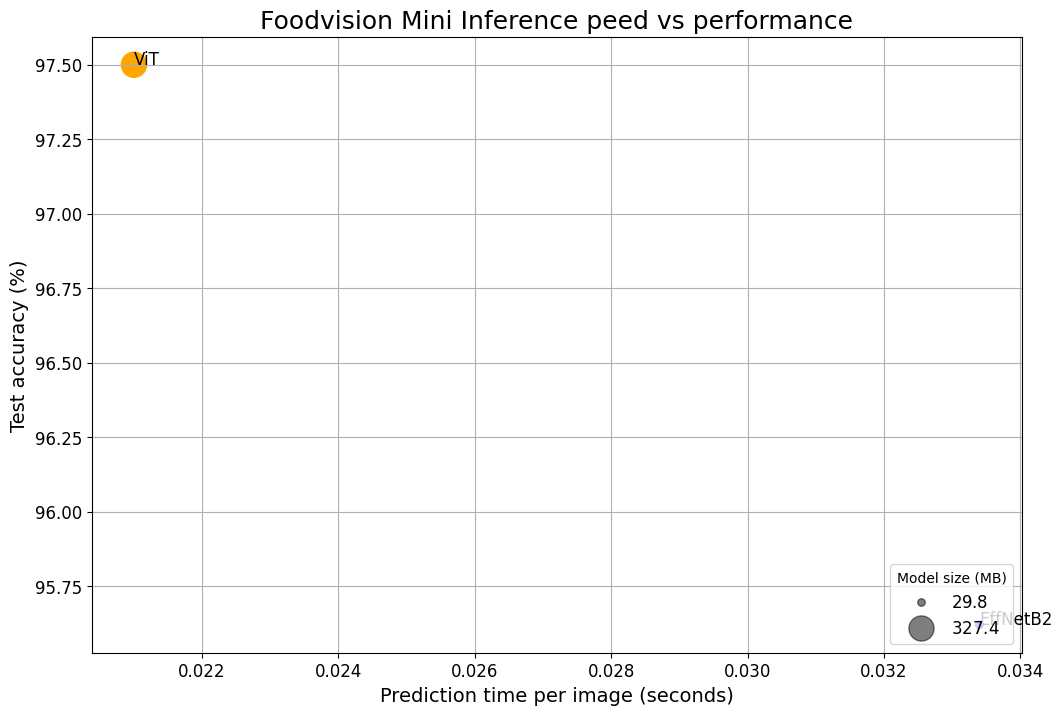

In [ ]:
# 1. Create a plot from model comparison DataFrame
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(data=df,
                     x="time_per_pred",
                     y="test_acc",
                     c=["blue", "orange"],
                     s="model_size (MB)")

# 2. Add title and labels to make the visualization more informative
ax.set_title("Foodvision Mini Inference peed vs performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True)

# 3. Annotate the samples on the scatter plot so we kow what is going on
for index, row in df.iterrows():
  ax.annotate(text=row["model"],
              xy=(row["time_per_pred"], row["test_acc"]),
              size=12)

# 4. Create a legend based on the model sizes (model_size (MB))
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles,
                              labels,
                              loc="lower right",
                              title="Model size (MB)",
                              fontsize=12)

# Save the figure
plt.savefig("09_foodvision_mini.png")

> with a larger model better performance but with sacrifice of speed

## 7. Bringing FoodVision Mini to life by creating a Gradio demo
https://www.gradio.app/

we chose vit for deployment.

https://huggingface.co/docs/transformers/model_doc/blip

what is gradio?
the fastest way to demo your machine learning models with a friendly web interface so that anyony can use them.


In [ ]:
# Import/ install Gradio
try:
  import gradio as gr
except:
  !pip -qqq install gradio
  import gradio as gr

print(f"Gradio version: {gr.__version__}")

Gradio version: 5.41.0


### 7.1 Gradio overview

Gradio helps you create machine learning demos.
why create a demo?
so other people try our models and we can test them in real_world.
Deployment is as important as training.
The overall promise of Gradio is to map inputs -> function/model -> output.

### 7.1 Creating a function to map our inputs and outputs

In [ ]:
# Put our model on the CPU
vit = vit.to("cpu")

# Check the device
next(iter(vit.parameters())).device

device(type='cpu')

In [ ]:
import gradio as gr

def image_classifier(inp):
  return {'cat': 0.3, 'dog': 0.7}

Let's create a function called predict() to go from input (food img) -> ML model (vit) -> output (food class)

In [ ]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
  # start a timer
  start_time = timer()

  # transform input image to use with vit
  transformed_image = vit_transform(img).unsqueeze(0)

  #put model into eval mode, make prediction
  vit.eval()

  with torch.inference_mode():
    pred = vit(transformed_image)

    pred_prob = torch.softmax(pred, dim=1)
    pred_label = torch.argmax(pred_prob)
    pred_class = class_names[pred_label]

  # create pred label and prob dict
  pred_dict = {class_names[i]: float(pred_prob[0][i]) for i in range(len(class_names))}

  # calculate pred time
  end_time = timer()
  pred_time = round(end_time - start_time, 4)

  # return pred dict and pred time
  return pred_dict, pred_time

In [ ]:
import random
from PIL import Image

# Get a list of all test paths
test_paths = list(Path(test_dir).glob("*/*.jpg"))

# Get a rondom image path
random_image_path = random.sample(test_paths, k=1)[0]

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] prediction on image on path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(pred_dict)
print(pred_time)

[INFO] prediction on image on path: data/pizza_steak_sushi_20_percent/test/sushi/1245545.jpg

{'pizza': 0.010047763586044312, 'steak': 0.002997487550601363, 'sushi': 0.9869547486305237}
0.8981


### 7.3 Creating a list of example images
The examples for Gradio can be created with the `example` parameter
https://www.gradio.app/guides/quickstart
https://www.gradio.app/docs/#building-demos

In [ ]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_paths, k=3)]

### 7.4 Building a Gradio interface
 usinf `gr.interface()`
 ```python
 input: image -> transform -> predict with vit -> output: pred, pred prob, time
 ```

In [ ]:
import gradio as gr

# Create title, description, and article
title = "FoodVision Mini 🥘🍪🍣🍕🥩"
description = "An [vit_b_16 feature extractor] (https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html)"
article = "Created as part of course PyTorch zero to mastery"

# Create the Gradio demo
demo = gr.Interface(
                    fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[
                        gr.Label(num_top_classes=3, label="Predictions"),
                        gr.Number(label="Prediction time (s)")
                    ],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article
)

# Launch the demooo!
demo.launch(debug=False, # Print errors locally?
            share=True)  # generate a publically shareable URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c466da702cf6d5ce30.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


https://huggingface.co/docs/hub/spaces

## 8. Turning our FoodVision Mini Gradio into a deployable app
our Gradio demos from Google Colab are fantastic but they expire within 72 hours.
To fix this, we are going to prepare our app files so we can host them on Hugging Face Spaces: https://huggingface.co/docs/hub/spaces

### 8.1 What is Hugging Face Spaces?

> Hugging Face Spaces offer a simple way to host ML demo apps directly on your profile or your organization’s profile. This allows you to create your ML portfolio, showcase your projects at conferences or to stakeholders, and work collaboratively with other people in the ML ecosystem.

Github -> share code ability, Hugging Face -> share ML ability.

https://git-lfs.com/ hugging face like the github of machine learning.

### 8.2 Deployed Gradio app interface

Let's start to put all of our app files into a single directory:

```
Colab -> folder with all Gradio files -> upload app files to Hugging Face Spaces -> deploy
```

By the end file structure will look like this:

```
demos/
    foodvision_mini/
      09_vit_feature_extractor.pth
      app.py
      examples/
        example_1.jpg
        example_2.jpg
        example_3.jpg
      model.py
      requirements.txt
```

why use this structure? it is simple to start with then experiment and update with time.

### 8.3 Creating a `demos` folder to store our FoodVision app files

In [ ]:
import shutil # to maniplute files and directories in python
from pathlib import Path

# Create FoodVision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# Remove files that might exist and create a new directory
if foodvision_mini_demo_path.exists():
  shutil.rmtree(foodvision_mini_demo_path)
  foodvision_mini_demo_path.mkdir(parents=True, exist_ok=True)

else:
  foodvision_mini_demo_path.mkdir(parents=True, exist_ok=True)

!ls demos/foodvision_mini/

### 8.4 Creating a folder of example images to use with our FoodVision Mini demo

What to do?
  * 3 images in `examples/` directory.
  *  Images should be from the test set.

In [ ]:
import shutil
from pathlib import Path

# Create an example directory
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents=True, exist_ok=True)

# Collect three test dataset images
foodvision_mini_examples = [Path('/content/data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg'),
                            Path('/content/data/pizza_steak_sushi_20_percent/test/steak/1166047.jpg'),
                            Path('/content/data/pizza_steak_sushi_20_percent/test/sushi/1245545.jpg')]

# Copy ythe three images to the example directory
for example in foodvision_mini_examples:
  destination = foodvision_mini_examples_path / example.name
  print(f"[INFO] copying {example} to {destination}.")
  shutil.copy2(src=example,
               dst=destination)

[INFO] copying /content/data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg to demos/foodvision_mini/examples/129666.jpg.
[INFO] copying /content/data/pizza_steak_sushi_20_percent/test/steak/1166047.jpg to demos/foodvision_mini/examples/1166047.jpg.
[INFO] copying /content/data/pizza_steak_sushi_20_percent/test/sushi/1245545.jpg to demos/foodvision_mini/examples/1245545.jpg.


Let's now verify that we can get a list of lists from our `example` directory.

In [ ]:
import os

# Get example of filepaths in a list of lists
example_list = [["examples/" + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/1245545.jpg'], ['examples/1166047.jpg'], ['examples/129666.jpg']]

### 8.5 Moving our trained ViT model to our FoodVision Mini demo directory

In [ ]:
import shutil

# Create a source path for our target model
vit_foodvision_mini_model_path = "models/vit.pth"

# Create a destination path for our target model
vit_foodvision_mini_model_destination = foodvision_mini_demo_path / vit_foodvision_mini_model_path.split("/")[1]

# Try to move model file
try:
  print(f"[INFO] Attempting to move {vit_foodvision_mini_model_path} to {vit_foodvision_mini_model_destination}")
  #!cp "models/vit.pth" "demos/foodvision_mini/"
  shutil.copy2(src=vit_foodvision_mini_model_path,
              dst=vit_foodvision_mini_model_destination)

  print("[INFO] model move complete.")

except:
  print(f"[INFO] No model found at {vit_foodvision_mini_model_path}, perhaps it is already moved.")
  print(f"[INFO] Model exists at {vit_foodvision_mini_model_destination}: {vit_foodvision_mini_model_destination.exists}")

[INFO] Attempting to move models/vit.pth to demos/foodvision_mini/vit.pth
[INFO] model move complete.


### 8.6 Turning off vit model into a python script (`model.py`)
we have a saved `.pth` model `state_dict` and eant to load it into a model instance.
Let's move our `create_vit_model()` function so we can reuse it.

In [ ]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision
from torch import nn

def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

def create_ViT(num_classes:int=3, seed=42):
  # 1. Setup the pretrained ViT weights
  weights = torchvision.models.ViT_B_16_Weights.DEFAULT

  # 2. Get the pretrained ViT transform
  transform = weights.transforms()

  # 3. Create the pretrained ViT instance
  model = torchvision.models.vit_b_16(weights=weights)

  # 4. Freeze the the hidden layers
  for param in model.parameters():
    param.requires_grad = False

  set_seeds(seed)
  torch.manual_seed(seed)
  # 5. Customize the head layer to num classes
  model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))

  return model, transform

Writing demos/foodvision_mini/model.py


### 8.7 Turning our FoodVision Mini Gradio app into a python script `app.py`

The `app.py` file will have four major parts:
1. Improts and class names setup
2. Model and transforms preparation
3. Predict function (`predict()`)
4. Gradio app - our Gradio interface + launch command.


In [ ]:
%%writefile demos/foodvision_mini/app.py

# 1. Imports and class names setup
import gradio as gr
import os
import torch

from model import create_ViT
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ['Pizza', 'Steak', 'sushi']

# 2. Model and transform preparation
vit, vit_transform = create_ViT(num_classes=len(class_names))

# Load saved weights
vit.load_state_dict(torch.load(f="vit.pth"), MAP_LOCATION=torch.device("cpu")) # load the model to cpu

# 3. predict function
def predict(img) -> Tuple[Dict, float]:
  # start a timer
  start_time = timer()

  # transform input image to use with vit
  transformed_image = vit_transform(img).unsqueeze(0)

  #put model into eval mode, make prediction
  vit.eval()

  with torch.inference_mode():
    pred = vit(transformed_image)

    pred_prob = torch.softmax(pred, dim=1)
    pred_label = torch.argmax(pred_prob)
    pred_class = class_names[pred_label]

  # create pred label and prob dict
  pred_dict = {class_names[i]: float(pred_prob[0][i]) for i in range(len(class_names))}

  # calculate pred time
  end_time = timer()
  pred_time = round(end_time - start_time, 4)

  # return pred dict and pred time
  return pred_dict, pred_time


# 4. Gradio app interface

# Create title, description, and article
title = "FoodVision Mini 🥘🍪🍣🍕🥩"
description = "An [vit_b_16 feature extractor] (https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html)"
article = "Created as part of course PyTorch zero to mastery"

# Create example list

example_list = [["examples/" + example] for example in os.listdir("examples/")]

# Create the Gradio demo
demo = gr.Interface(
                    fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[
                        gr.Label(num_top_classes=3, label="Predictions"),
                        gr.Number(label="Prediction time (s)")
                    ],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article
)

# Launch the demooo!
demo.launch(debug=False, # Print errors locally?
            share=True)  # generate a publically shareable URL

Writing demos/foodvision_mini/app.py


### 8.7 Creating `requirements.txt`

torch, torchvision, gradio

In [ ]:
%%writefile demos/foodvision_mini/requirements.txt
torch==2.6.0
torchvision==0.21.0
gradio==5.41.0

Writing demos/foodvision_mini/requirements.txt


## 9. Deploying FoodVision Mini to Hugging Face Space

There are two main ways for uploading to a Hugging Face Space/repository.

* Uploading via the hugging face web interface.
* Uploading via the command line or terminal.
  * You can also use the hugging face library.

### Downloading our FoodVision Mini app file
we want to download `foodvision_mini` files into Hugging Face space.

In [ ]:
!ls demos/foodvision_mini/

app.py	examples  model.py  requirements.txt  vit.pth


In [ ]:
# Change into the foodvision mini directory and zip it from the inside
!cd demos/foodvision_mini/ && zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__" "*ipynb_checkpoints*"

  adding: app.py (deflated 54%)
  adding: examples/ (stored 0%)
  adding: examples/1245545.jpg (deflated 0%)
  adding: examples/1166047.jpg (deflated 1%)
  adding: examples/129666.jpg (deflated 0%)
  adding: model.py (deflated 52%)
  adding: requirements.txt (deflated 8%)
  adding: vit.pth (deflated 7%)


In [ ]:
# Download
try:
  from google.colab import files
  files.download("demos/foodvision_mini.zip")
except:
  print(f"Not running in Google Colab, can not run google.colab.files.download(), please download manually.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9.2 Running our Gradio demo app locally


### 9.3 Uploading our FoodVision Mini Gradio demo to Hugging Face Spaces

Steps:
1. Sign up for a n account -> 2. Start a new Space -> 3. Gve the space a name ->select a license (ex MIT) -> Select Gradio SDk -> Space public or private -> click `create space.`

Clone the space with terminal ->

-----
we can also share our app by embedding it.

In [ ]:
# Ipython is a library to help make python interactive
from IPython.display import IFrame # IFrame is a way to embed widgets

# Embed FoodVision Mini Gradio demo
IFrame(src="https://hf.space/embed/esraalmaeeni/FoodVision-mini/+", width=900, height=750)

## 10. Creating FoodVision Big

In [ ]:
effnetb2_food101, effnetb2_transform = create_effnetb2(num_classes=101)

In [ ]:
from torchinfo import summary

summary(effnetb2_food101,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 10.1 Getting transforms

with more dataset, overfitting become kind of a problem, that is we need to introduce a new kind of transform.

In [ ]:
food101_transforms = torchvision.transforms.Compose([
  torchvision.transforms.TrivialAugmentWide(),
  effnetb2_transform]) # for train data

In [ ]:
effnetb2_transform # for test data

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

### 10.2 Gettinf Food101 Dataset for foodvision
https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.Food101.html

In [ ]:
from torchvision import datasets

# Setup data directory
from pathlib import Path
data_dir = Path("data/")

# Get the training data (750 x 101 classes)
train_data = datasets.Food101(root=data_dir,
                              split="train",
                              transform=food101_transforms,
                              download=True)

# Get the testing data (250 x 101 classes)
test_data = datasets.Food101(root=data_dir,
                             split="test",
                             transform=effnetb2_transform,
                             download=True)

100%|██████████| 5.00G/5.00G [02:49<00:00, 29.5MB/s]


In [ ]:
# Get Food101 class names
food101_class_names = train_data.classes
food101_class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

### 10.3 Creating a subset of the Food101 dataset for faster experimenting

why subset? we want our first few experiments to run as quick as possible.
We know food101 dataset works well, but as upgrading for the first time to 101 classes, we will creat 20% subset from the food dataset.

In [ ]:
from torch.utils.data import random_split

def split_dataset(dataset:torchvision.datasets,
                  split_size:float=0.2,
                  seed:int=42):
  length_1 = int(len(dataset) * split_size)
  length_2 = len(dataset) - length_1

  # print out info
  print(f"[INFO] Splitting dataset of length {len(dataset)} into splits of size {length_1} and {length_2}" )

  # Create splits with given random seed
  random_split_1, random_split_2 = torch.utils.data.random_split(dataset,
                                                            lengths=[length_1, length_2],
                                                            generator=torch.manual_seed(seed))

  return random_split_1, random_split_2

In [ ]:
train_data_food101_20_precent, _ = split_dataset(dataset=train_data,
                                                 split_size=0.2)

test_data_food101_20_precent, _ = split_dataset(dataset=test_data,
                                                split_size=0.2)

[INFO] Splitting dataset of length 75750 into splits of size 15150 and 60600
[INFO] Splitting dataset of length 25250 into splits of size 5050 and 20200


In [ ]:
len(train_data_food101_20_precent), len(test_data_food101_20_precent)

(15150, 5050)

> Start small and increase your experimenting size when necessary.

### 10.4 Turning our Food101 dataset into `DataLoader`s

In [ ]:
import torch

NUM_WORKERS = 2
BATCH_SIZE = 32

# Create Food101 20 training DataLoader
train_dataloader_food101_20_precent = torch.utils.data.DataLoader(dataset=train_data_food101_20_precent,
                                                                  batch_size=BATCH_SIZE,
                                                                  shuffle=True,
                                                                  num_workers=NUM_WORKERS)

# Create Food101 20 testing DataLoader
test_dataloader_food101_20_precent = torch.utils.data.DataLoader(dataset=test_data_food101_20_precent,
                                                                  batch_size=BATCH_SIZE,
                                                                  shuffle=False,
                                                                  num_workers=NUM_WORKERS)

### 10.5 Training FoodVision Big

Things for training:
* 5 epochs
* Optimizer: `torch.optim.Adam(lr=1e-3)`
* Loss function: `torch.nn.CrossEntropy(label smoothing=0.1)`

why use label smoothing?
label smoothing: a regularization technique that prevent overfitting, overconfidence, introduce noice to labels.

without label smoothing and 5 classes:
```
[0.00, 0.00, 0.99, 0.01, 0.00]
```
with label smoothing and 5 classes:
```
[0.01, 0.01, 0.96, 0.01, 0.01]
```


In [ ]:
from going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

# Setup loss
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

# Want to beat the food101 paper's result of 56.4% accuracy with 20% of the data
set_seeds()
effnetb2_food101_results = engine.train(model=effnetb2_food101,
                                        train_dataloader=train_dataloader_food101_20_precent,
                                        test_dataloader=test_dataloader_food101_20_precent,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=5,
                                        device=device)



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.6422 | train_acc: 0.2795 | test_loss: 2.7824 | test_acc: 0.4903
Epoch: 2 | train_loss: 2.8626 | train_acc: 0.4410 | test_loss: 2.4729 | test_acc: 0.5334
Epoch: 3 | train_loss: 2.6559 | train_acc: 0.4866 | test_loss: 2.3633 | test_acc: 0.5556
Epoch: 4 | train_loss: 2.5455 | train_acc: 0.5124 | test_loss: 2.3022 | test_acc: 0.5751
Epoch: 5 | train_loss: 2.4963 | train_acc: 0.5235 | test_loss: 2.2799 | test_acc: 0.5810


### 10.6 Inspecting loss curves of FoodVision Big model

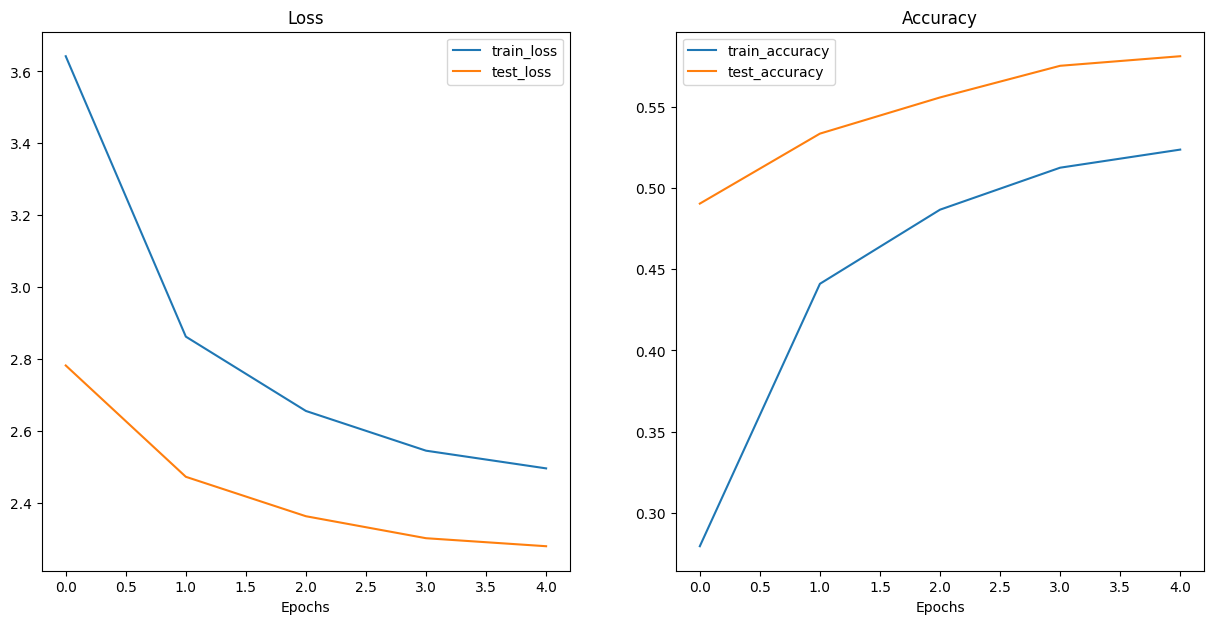

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_results)

### 10.7 Save and load FoodVision Big model

In [ ]:
from going_modular import utils

# Create a model path
effnetb2_food101_model_path = "food101_effnetb2.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models/food101_effnetb2.pth


In [ ]:
# Create Food101 compatible EffNetB2 instance
loaded_effnetb2_food101, effnetb2_transform = create_effnetb2(num_classes=101)

# Load the saved model stat dict
loaded_effnetb2_food101.load_state_dict(torch.load("models/food101_effnetb2.pth"))

<All keys matched successfully>

### 10.8 Checking FoodVision Big model size

In [ ]:
from pathlib import Path

# Get the model size in bytes then convert to megabyte
pretrained_effnetb2_food101_model_size = Path("models", effnetb2_food101_model_path).stat().st_size // (1024 * 1024)
print(f"Pretrained Effnetb2 feature extractor model size: {pretrained_effnetb2_food101_model_size}")

Pretrained Effnetb2 feature extractor model size: 30


## 11. Turning our FoodVision Big model into a deployable app

Why deploying it? to see how it goes in real world.
Outline of FoodVision Big:
```
demos/
  foodvision_big/
    food101_effnetb2.pth
    examples/
    requirements.txt
    class_names.txt
    model.py
    app.py
```

In [ ]:
from pathlib import Path

# Create FoodVision Big demo path
foodvision_big_demo_path = Path("demos/foodvision_big/")

# Make foodvision Big demo dictionary
foodvision_big_demo_path.mkdir(parents=True, exist_ok=True)

# Make FoodVision Big demo examples directory
(foodvision_big_demo_path / "examples").mkdir(parents=True, exist_ok=True)

In [ ]:
ls demos/foodvision_big/

examples/


### 11.1 Downloading an example image and moving it to the `example` directory

In [ ]:
# Download and move example image
!wget https://raw.githubusercontent.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice/refs/heads/main/images/pizza.jpg
!mv pizza.jpg demos/foodvision_big/examples/pizza.jpg

--2025-08-11 15:42:38--  https://raw.githubusercontent.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice/refs/heads/main/images/pizza.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3291492 (3.1M) [image/jpeg]
Saving to: ‘pizza.jpg’

pizza.jpg           100%[===================>]   3.14M  --.-KB/s    in 0.08s   

2025-08-11 15:42:39 (39.7 MB/s) - ‘pizza.jpg’ saved [3291492/3291492]



In [ ]:
!mv models/food101_effnetb2.pth demos/foodvision_big/

### 11.2 Saving Food101 class names to file (`class_names.txt`)



In [ ]:
# Check out the first food101 class names
food101_class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
# Create Path to food101 class names
foodvision_big_class_names_path = foodvision_big_demo_path / "class_names.txt"

# Write food101 class names to text file
with open(foodvision_big_class_names_path, "w") as f:
  print(f"[INFO] Saving Food101 class names to {foodvision_big_class_names_path}")
  f.write("\n". join(food101_class_names)) # new line per class name

[INFO] Saving Food101 class names to demos/foodvision_big/class_names.txt


In [ ]:
# Open food101 class names file and read each line into a list
with open(foodvision_big_class_names_path, "r") as f:
  food101_class_names_loaded = [food.strip() for food in f.readlines()]
food101_class_names_loaded[:5]

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']

### 11.3 Turning our FoodVision big model into `model.py`

In [ ]:
%%writefile demos/foodvision_big/model.py
import torch
import torchvision
from torch import nn

def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

def create_effnetb2(num_classes:int= 3, seed:int= 42):

  # 1. Setup the pretrained EffNetB2 wights
  effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

  # 2. Get the effnetb2 transform
  effnetb2_transforms = effnetb2_weights.transforms()

  # 3. Setup the pretrained model instance
  effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

  # 4. Freeze the base layers in the model
  for param in effnetb2.parameters():
    param.requires_grad=False

  # 5. Customize the head layers
  set_seeds(seed)
  effnetb2.classifier = nn.Sequential(
                                      nn.Dropout(p=0.3, inplace=True),
                                      nn.Linear(in_features=1408, out_features=num_classes, bias=True))
  return effnetb2, effnetb2_transforms

Writing demos/foodvision_big/model.py


### 11.4 Turning our FoodVision Big Gradio app into a python scropt (`app.py`)

The `app.py` file will have four major parts:
1. imports and class names setup.
2. model and transform preparation.
3. predict function.
4. Gradio app.

In [ ]:
%%writefile demos/foodvision_big/app.py

# 1. Imports and class names setup
import gradio as gr
import os
import torch

from model import create_effnetb2
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
with open("class names_names.txt", "r") as f:
  class_names = [food_name.strip() for food_name in f.readlines()]

# 2. Model and transform preparation
effnetb2, effnetb2_transform = create_ViT(num_classes=101)

# Load saved weights
effnetb2.load_state_dict(torch.load(f="food101_effnetb2.pth"), MAP_LOCATION=torch.device("cpu")) # load the model to cpu

# 3. predict function
def predict(img) -> Tuple[Dict, float]:
  # start a timer
  start_time = timer()

  # transform input image to use with vit
  transformed_image = effnetb2_transform(img).unsqueeze(0)

  #put model into eval mode, make prediction
  effnetb2.eval()

  with torch.inference_mode():
    pred = effnetb2(transformed_image)

    pred_prob = torch.softmax(pred, dim=1)
    pred_label = torch.argmax(pred_prob)
    pred_class = class_names[pred_label]

  # create pred label and prob dict
  pred_dict = {class_names[i]: float(pred_prob[0][i]) for i in range(len(class_names))}

  # calculate pred time
  end_time = timer()
  pred_time = round(end_time - start_time, 4)

  # return pred dict and pred time
  return pred_dict, pred_time


# 4. Gradio app interface

# Create title, description, and article
title = "FoodVision Big 🥘🍪"
description = "An [EffNetB2 feature extractor] (https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html) to classify 101 food classes from Food101 dataset."
article = "Created as project of course PyTorch zero to mastery"

# Create example list

example_list = [["examples/" + example] for example in os.listdir("examples/")]

# Create the Gradio demo
demo = gr.Interface(
                    fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[
                        gr.Label(num_top_classes=3, label="Predictions"),
                        gr.Number(label="Prediction time (s)")
                    ],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article
)

# Launch the demooo!
demo.launch()

Writing demos/foodvision_big/app.py


In [ ]:
%%writefile demos/foodvision_big/requirements.txt
torch==2.6.0
torchvision==0.21.0
gradio==5.41.0

Writing demos/foodvision_big/requirements.txt


### 11.6 Downloading our FoodVision Big app files

In [ ]:
# Change into foodvision_big directory and then zip from the inside
!cd demos/foodvision_big/ && zip -r ../foodvision_big.zip * -x "*.pyc" "*.ipynb" "*__pycache__" "*ipynb_checkpoints*"

  adding: app.py (deflated 54%)
  adding: class_names.txt (deflated 48%)
  adding: examples/ (stored 0%)
  adding: examples/pizza.jpg (deflated 0%)
  adding: food101_effnetb2.pth (deflated 8%)
  adding: model.py (deflated 55%)
  adding: requirements.txt (deflated 8%)


In [ ]:
# Download
try:
  from google.colab import files
  files.download("demos/foodvision_big.zip")
except:
  print(f"Not running in Google Colab, can not run google.colab.files.download(), please download manually.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 11.7 Deploying FoodVision Big to HF